# simple code example

### Making dataset, and visualizing it

In [1]:
from sklearn.datasets import make_regression
import numpy as np

In [2]:
x, y = make_regression(n_samples=4, n_informative=1, n_features=1, n_targets=1, noise=50, random_state=2)

In [3]:
x, y

(array([[-0.05626683],
        [ 1.64027081],
        [-0.41675785],
        [-2.1361961 ]]),
 array([ -33.22643162,  113.63119352,  -71.24193395, -164.84914944]))

In [4]:
import matplotlib.pyplot as plt

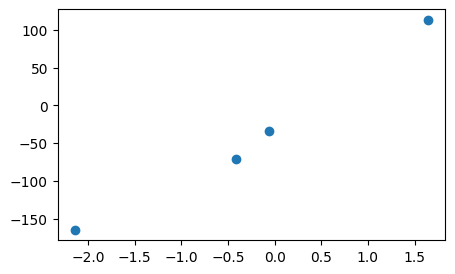

In [5]:
plt.figure(figsize=(5,3))
plt.scatter(x, y)

### Apply OLS (Ordinary Least Squares)

In [6]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [7]:
lr.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
lr.coef_

array([73.98362694])

In [9]:
lr.intercept_

np.float64(-20.999972249046646)

In [10]:
y_pred = lr.predict(x)

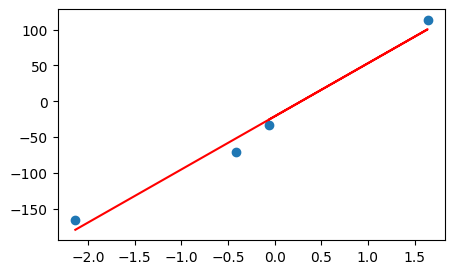

In [11]:
plt.figure(figsize=(5,3))
plt.scatter(x, y)
plt.plot(x, y_pred, color='r')

### Apply Gradient Descent assuming
#### m = 73.9836, b = 0

In [12]:
y_pred1 = ((73.9836*x)+0).reshape(4)
y_pred1

array([  -4.16282244,  121.35313938,  -30.83324588, -158.04347746])

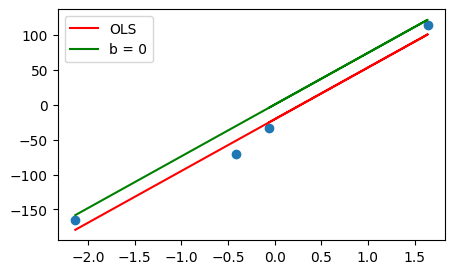

In [13]:
plt.figure(figsize=(5,3))
plt.scatter(x, y)
plt.plot(x, y_pred, color='r', label='OLS')
plt.plot(x, y_pred1, color='g', label='b = 0')
plt.legend()

### Iteration - 1

In [14]:
m = 73.9836
b = 0

In [15]:
loss_slope = -2 * np.sum(y - m*x.ravel() - b)
loss_slope

np.float64(167.99983019216342)

In [16]:
# Assume learning rate = 0.1
learn_rate = 0.1
step_size = learn_rate * loss_slope
step_size

np.float64(16.79998301921634)

In [17]:
# Calculate new b
b = b - step_size
b

np.float64(-16.79998301921634)

In [18]:
# checking new line
y_pred2 = (m*x+b).reshape(4)
y_pred2

array([ -20.96280546,  104.55315636,  -47.6332289 , -174.84346048])

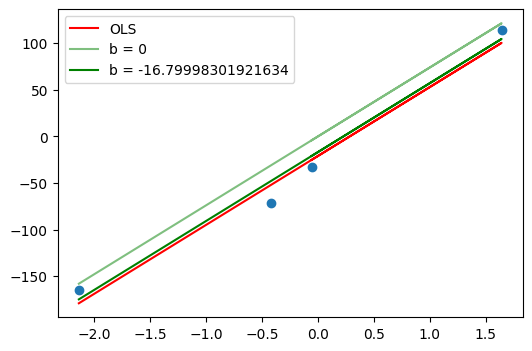

In [19]:
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, y_pred, color='r', label='OLS')
plt.plot(x, y_pred1, color='g', alpha=0.5, label='b = 0')
plt.plot(x, y_pred2, color='g', label='b = {}'.format(b))
plt.legend()
plt.show()

### Iteration - 2

In [20]:
loss_slope = -2 * np.sum(y - m*x.ravel() - b)
loss_slope

np.float64(33.599966038432676)

In [21]:
step_size = learn_rate * loss_slope
step_size

np.float64(3.3599966038432676)

In [22]:
b = b - step_size
b

np.float64(-20.15997962305961)

In [23]:
y_pred3 = m * x + b
y_pred

array([ -25.1627962 ,  100.35321131,  -51.83322935, -179.04350725])

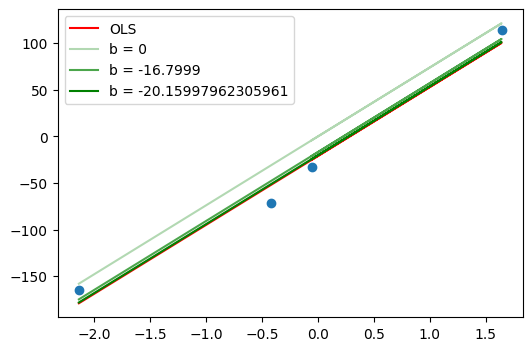

In [24]:
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, y_pred, color='r', label='OLS')
plt.plot(x, y_pred1, color='g', alpha=0.3, label='b = 0')
plt.plot(x, y_pred2, color='g', alpha=0.7, label='b = -16.7999')
plt.plot(x, y_pred3, color='g', label='b = {}'.format(b))
plt.legend()
plt.show()

### Finding line using a loop

In [25]:
x

array([[-0.05626683],
       [ 1.64027081],
       [-0.41675785],
       [-2.1361961 ]])

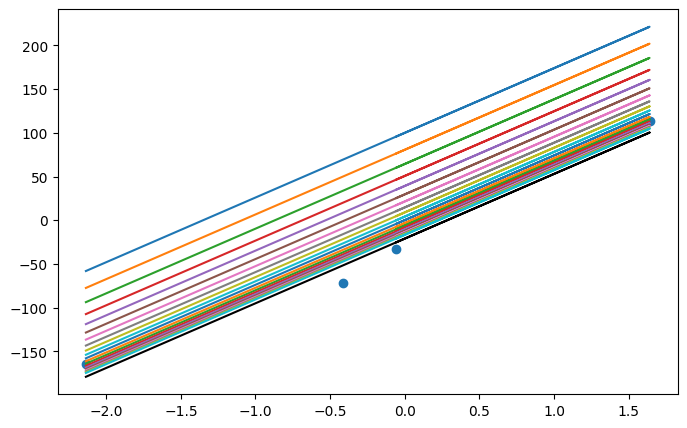

In [49]:
m = 73.9836
b = 100
learn_r = 0.02

epochs = 20
plt.figure(figsize=(8,5))
plt.scatter(x, y)
plt.plot(x, lr.predict(x), color='black')
for i in range(epochs):
    y_pred = m*x + b
    loss_slope = -2 * np.sum(y - m*x.ravel() - b)
    b = b - learn_r*loss_slope
    plt.plot(x, y_pred)